In [ ]:
CARGAR DATOS

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import pearsonr
from scipy.interpolate import make_interp_spline

# Path configuration
base_path = os.path.join(os.path.expanduser("~"), "Desktop", "COSES UNI", "TFG", "DATOS")

def load_tfg_data(file_name):
    # Load data skipping the first 8 rows (Giovanni metadata)
    df = pd.read_csv(os.path.join(base_path, file_name), skiprows=8, sep=None, engine='python')
    
    # Force clean column names
    df.columns = ['date', 'value'] 
    
    # Convert types
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    # Data cleaning
    df.dropna(inplace=True)
    df = df[df['value'] >= 0].copy()
    
    # Add time features
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    
    return df

# Load all datasets
df_wmb_vap = load_tfg_data("WMBwatervapor.csv")
df_emb_vap = load_tfg_data("EMBwatervapor.csv")
df_wmb_evap = load_tfg_data("WMBevap.csv")
df_emb_evap = load_tfg_data("EMBevap.csv")

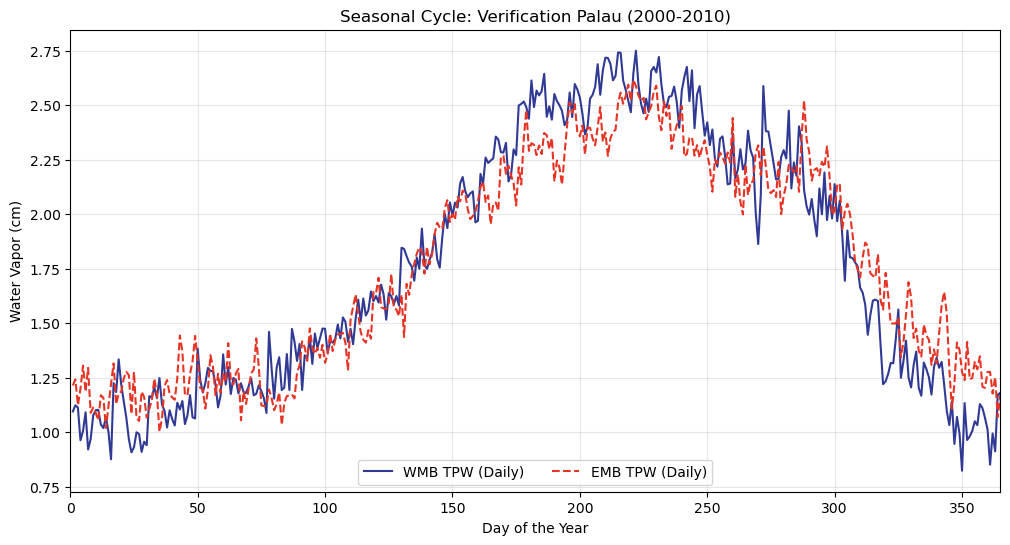

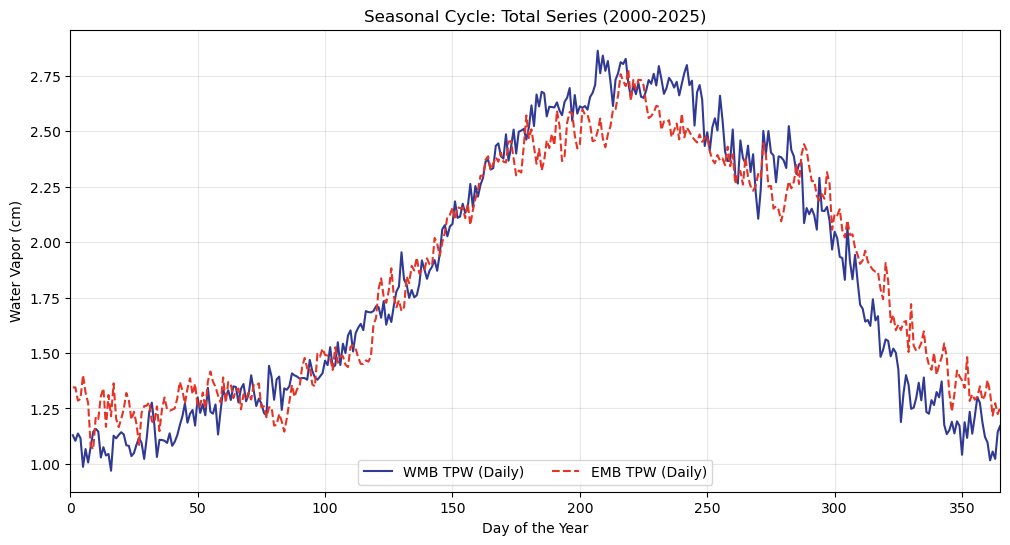

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

def generate_pure_seasonal_cycle(df_v, df_e, label, start_year, end_year):
    # Year filtering
    mask_v = (df_v['date'].dt.year >= start_year) & (df_v['date'].dt.year <= end_year)
    mask_e = (df_e['date'].dt.year >= start_year) & (df_e['date'].dt.year <= end_year)
    dv = df_v[mask_v].copy()
    de = df_e[mask_e].copy()

    # Daily mean
    vapor_series = dv.groupby('day_of_year')['value'].mean()

    # Evaporation
    monthly_evap = de.groupby(de['date'].dt.month)['value'].mean()
    x = np.array(monthly_evap.index)
    y = np.array(monthly_evap.values)
    x_new = np.linspace(1, 12, 365)
    spl = make_interp_spline(x, y, k=3)
    evap_series = spl(x_new) * 86400 * 0.1 # Conversion factor

    return vapor_series, evap_series

# Sub-period configuration
periods = [
    {"label": "Verification Palau (2000-2010)", "start": 2000, "end": 2010},
    {"label": "Total Series (2000-2025)", "start": 2000, "end": 2025}
]

for p in periods:
    v_wmb, e_wmb = generate_pure_seasonal_cycle(df_wmb_vap, df_wmb_evap, p['label'], p['start'], p['end'])
    v_emb, e_emb = generate_pure_seasonal_cycle(df_emb_vap, df_emb_evap, p['label'], p['start'], p['end'])
    
    fig, ax1 = plt.subplots(figsize=(12,6))
    ax1.plot(v_wmb, color='#303a94', label='WMB TPW (Daily)')
    ax1.plot(v_emb, color='#e63324', label='EMB TPW (Daily)', linestyle='--')
    ax1.set_ylabel('Water Vapor (cm)')
    ax1.set_xlabel('Day of the Year')
    ax1.set_title(f"Seasonal Cycle: {p['label']}")
    plt.legend(loc='lower center', ncol=2)
    plt.grid(True, alpha=0.3)
    ax1.set_xlim(0, 365)
    plt.show()

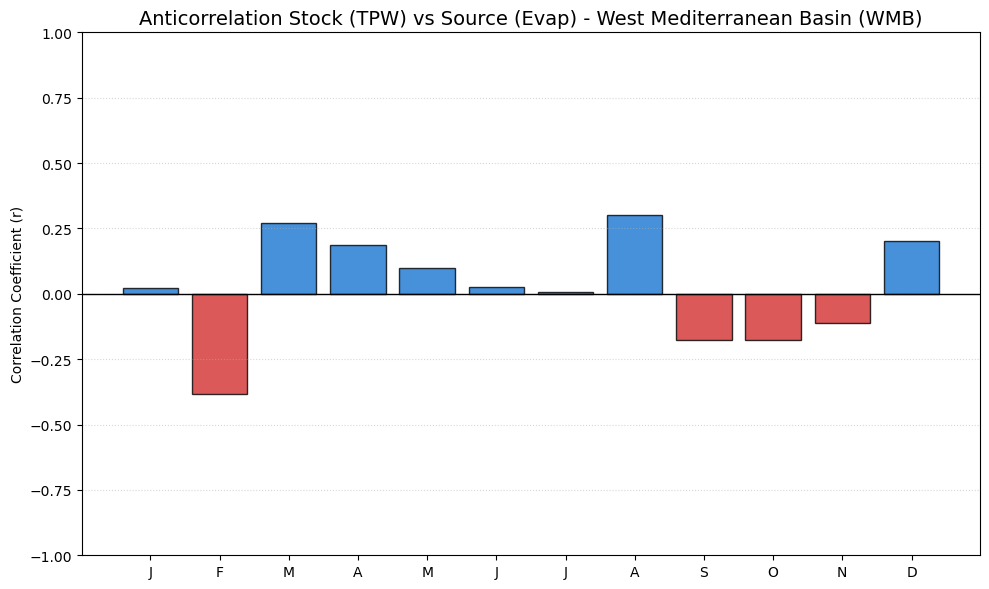

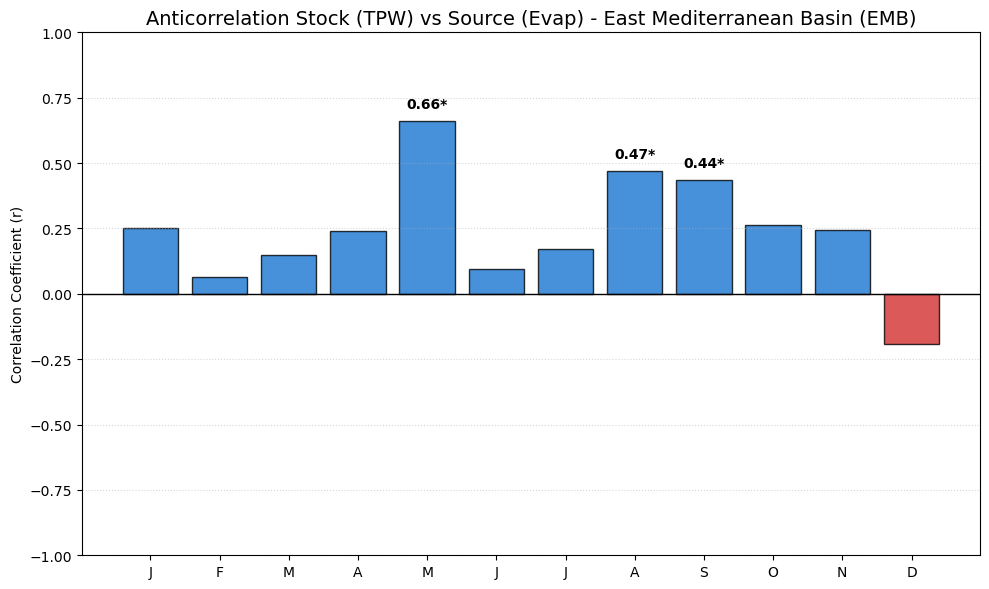

In [41]:
from scipy.stats import pearsonr


def calculate_anticorrelation(df_vap, df_evap, basin_name):
    df_vap = df_vap[df_vap['date'].dt.year <= 2025].copy()
    df_evap = df_evap[df_evap['date'].dt.year <= 2025].copy()
   
    
    # 1. Merge Vapor and Evaporation from the same basin by date
    df_merge = pd.merge(df_vap[['date', 'value', 'month']], 
                        df_evap[['date', 'value']], 
                        on='date', suffixes=('_vap', '_evap'))
    
    months = range(1, 13)
    corrs = []
    p_vals = []

    for m in months:
        data = df_merge[df_merge['month'] == m]
        if len(data) > 10:
            # Correlate Stock (Vapor) vs Source (Evaporation)
            r, p = pearsonr(data['value_vap'], data['value_evap'])
            corrs.append(r)
            p_vals.append(p)
        else:
            corrs.append(0)
            p_vals.append(1)

    # 2. Bar Chart
    plt.figure(figsize=(10, 6))
    
    # Colors: Red for negative correlation (anticorrelation), Blue for positive
    colors = ['#d32f2f' if r < 0 else '#1976d2' for r in corrs]
    bars = plt.bar(months, corrs, color=colors, edgecolor='black', alpha=0.8)
    
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Anticorrelation Stock (TPW) vs Source (Evap) - {basin_name}", fontsize=14)
    plt.ylabel("Correlation Coefficient (r)")
    plt.xticks(months, ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    plt.ylim(-1, 1)
    plt.grid(axis='y', linestyle=':', alpha=0.5)

    # Add labels for statistically significant correlations (p < 0.05)
    for bar, r, p in zip(bars, corrs, p_vals):
        if p < 0.05:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.05 if r > 0 else -0.1), 
                     f"{r:.2f}*", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# EXECUTE 
calculate_anticorrelation(df_wmb_vap, df_wmb_evap, "West Mediterranean Basin (WMB)")
calculate_anticorrelation(df_emb_vap, df_emb_evap, "East Mediterranean Basin (EMB)")

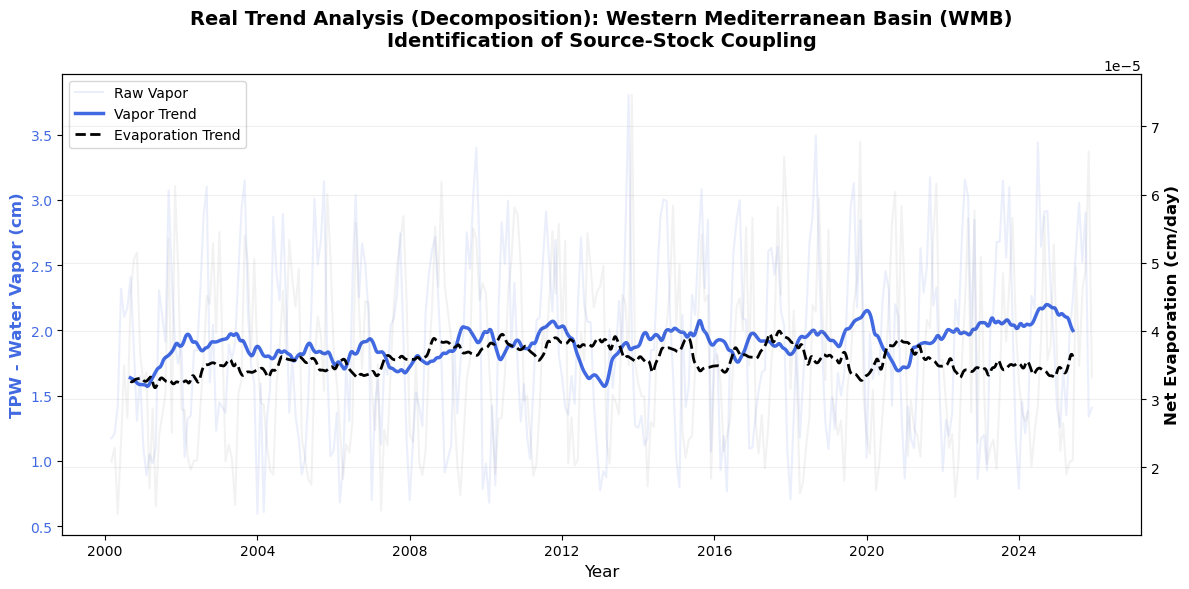


 TREND RESULTS - Western Mediterranean Basin (WMB)
-> Pearson Correlation (Trends): -0.1550
-> P-value: 1.0450e-49
-> The coupling between evaporation trend and stock is STATISTICALLY SIGNIFICANT.


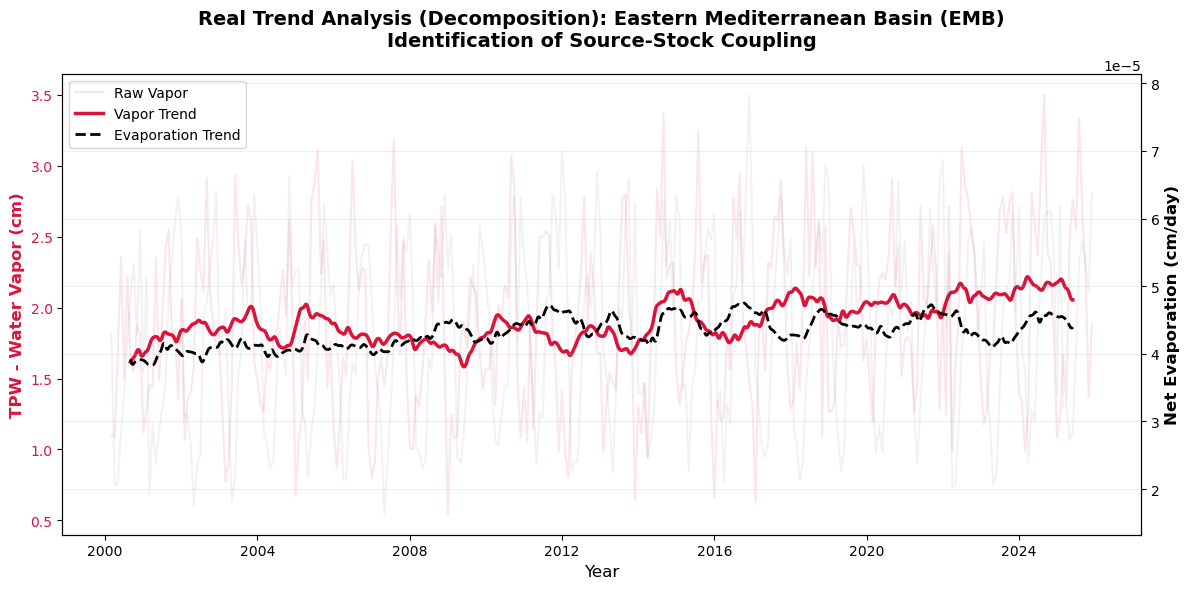


 TREND RESULTS - Eastern Mediterranean Basin (EMB)
-> Pearson Correlation (Trends): 0.3067
-> P-value: 2.7823e-196
-> The coupling between evaporation trend and stock is STATISTICALLY SIGNIFICANT.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from statsmodels.tsa.seasonal import seasonal_decompose

def analyze_unified_trend_7_3(df_vap, df_evap, site_name, color_main):
    df_vap = df_vap[df_vap['date'].dt.year <= 2025].copy()
    df_evap = df_evap[df_evap['date'].dt.year <= 2025].copy()
    
    # 1. Data synchronization and continuous series preparation
    df = pd.merge(df_vap[['date', 'value']], df_evap[['date', 'value']], on='date', suffixes=('_vap', '_evap'))
    df = df.sort_values('date').set_index('date')
    
    # Daily resampling to ensure no missing days
    df_resampled = df.resample('D').mean().interpolate(method='linear')
    
    # 2. Seasonal Decomposition to extract the real TREND
    res_vap = seasonal_decompose(df_resampled['value_vap'], model='additive', period=365)
    res_evap = seasonal_decompose(df_resampled['value_evap'], model='additive', period=365)
    
    # Extract trends (removes seasonality and noise)
    trend_vap = res_vap.trend
    trend_evap = res_evap.trend

    # 3. Statistical calculation on the trend
    # Remove NaNs generated by decomposition at the edges
    valid_mask = trend_vap.notna() & trend_evap.notna()
    coef, p_val = pearsonr(trend_vap[valid_mask], trend_evap[valid_mask])

    # 4. Professional Visualization
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Left Axis: Water Vapor Trend
    ax1.plot(df_resampled.index, df_resampled['value_vap'], color=color_main, alpha=0.1, label='Raw Vapor')
    ax1.plot(trend_vap.index, trend_vap, color=color_main, linewidth=2.5, label='Vapor Trend')
    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('TPW - Water Vapor (cm)', color=color_main, fontweight='bold', fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color_main)

    # Right Axis: Evaporation Trend
    ax2 = ax1.twinx()
    ax2.plot(df_resampled.index, df_resampled['value_evap'], color='black', alpha=0.05) # Very faint raw data
    ax2.plot(trend_evap.index, trend_evap, color='black', linewidth=2, linestyle='--', label='Evaporation Trend')
    ax2.set_ylabel('Net Evaporation (cm/day)', color='black', fontweight='bold', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='black')

    # Title and Legend configuration
    plt.title(f"Real Trend Analysis (Decomposition): {site_name}\nIdentification of Source-Stock Coupling", fontsize=14, fontweight='bold', pad=20)
    
    # Join legends from both axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, fontsize=10)

    plt.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()

    # 5. Statistical results output
    print(f"\n" + "="*40)
    print(f" TREND RESULTS - {site_name}")
    print(f"="*40)
    print(f"-> Pearson Correlation (Trends): {coef:.4f}")
    print(f"-> P-value: {p_val:.4e}")
    if p_val < 0.05:
        print("-> The coupling between evaporation trend and stock is STATISTICALLY SIGNIFICANT.")
    print("="*40)

# --- EXECUTION ---

# Analyze WMB (West)
analyze_unified_trend_7_3(df_wmb_vap, df_wmb_evap, "Western Mediterranean Basin (WMB)", "royalblue")

# Analyze EMB (East)
analyze_unified_trend_7_3(df_emb_vap, df_emb_evap, "Eastern Mediterranean Basin (EMB)", "crimson")



--- ZONE ANALYSIS: WMB (Vapor) ---
2000-2009: Mean = 1.77 cm, Std = 0.66, Trend = 0.0152 cm/year
2015-2025: Mean = 1.92 cm, Std = 0.73, Trend = 0.0278 cm/year
Change in Mean: +8.74%
Change in Variability: +10.32%
p-value (Welch's t-test): 8.5583e-22



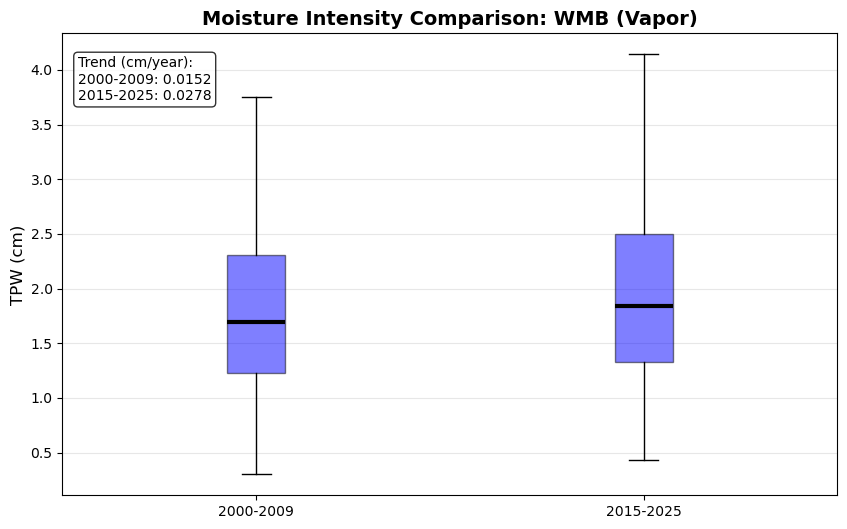


--- ZONE ANALYSIS: EMB (Vapor) ---
2000-2009: Mean = 1.75 cm, Std = 0.58, Trend = 0.0137 cm/year
2015-2025: Mean = 1.96 cm, Std = 0.66, Trend = 0.0198 cm/year
Change in Mean: +11.48%
Change in Variability: +14.11%
p-value (Welch's t-test): 6.9521e-44



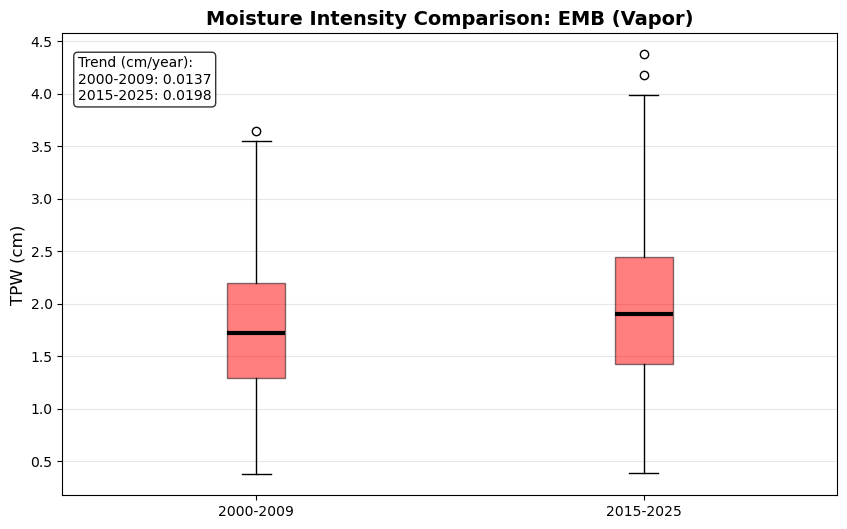

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def analyze_subperiods_7_4(df, site_name, color):
    # 1. Split data into the two subperiods (baseline 2000-2009, recent 2015-2025)
    period_1 = df[(df['date'].dt.year >= 2000) & (df['date'].dt.year <= 2009)].copy()
    period_2 = df[(df['date'].dt.year >= 2015) & (df['date'].dt.year <= 2025)].copy()

    if period_1.empty or period_2.empty:
        print(f"Insufficient data in one of the periods for {site_name}")
        return

    # 2. Calculate intensity metrics (Mean and Standard Deviation)
    mean_p1 = period_1['value'].mean()
    std_p1 = period_1['value'].std()
    mean_p2 = period_2['value'].mean()
    std_p2 = period_2['value'].std()

    # 3. Linear trend (slope) using polyfit (degree 1) on the daily time series
    slope_p1_per_day = np.polyfit(range(len(period_1)), period_1['value'], 1)[0]
    slope_p2_per_day = np.polyfit(range(len(period_2)), period_2['value'], 1)[0]
    # Convert to cm/year
    slope_p1 = slope_p1_per_day * 365.25
    slope_p2 = slope_p2_per_day * 365.25

    # 4. Visualization: Boxplot Comparison
    plt.figure(figsize=(10, 6))
    data_to_plot = [period_1['value'], period_2['value']]
    median_style = dict(linestyle='-', linewidth=3, color='black')
    box = plt.boxplot(data_to_plot, patch_artist=True, labels=['2000-2009', '2015-2025'], medianprops=median_style)

    for patch in box['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    plt.title(f"Moisture Intensity Comparison: {site_name}", fontsize=14, fontweight='bold')
    plt.ylabel("TPW (cm)", fontsize=12)
    plt.grid(True, axis='y', alpha=0.3)

    # Add text box with the computed trends (cm/year)
    text_str = f"Trend (cm/year):\n2000-2009: {slope_p1:.4f}\n2015-2025: {slope_p2:.4f}"
    plt.text(0.02, 0.95, text_str, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 5. Results report
    mean_change = ((mean_p2 - mean_p1) / mean_p1) * 100
    intensity_change = ((std_p2 - std_p1) / std_p1) * 100

    print(f"\n--- ZONE ANALYSIS: {site_name} ---")
    print(f"2000-2009: Mean = {mean_p1:.2f} cm, Std = {std_p1:.2f}, Trend = {slope_p1:.4f} cm/year")
    print(f"2015-2025: Mean = {mean_p2:.2f} cm, Std = {std_p2:.2f}, Trend = {slope_p2:.4f} cm/year")
    print(f"Change in Mean: {mean_change:+.2f}%")
    print(f"Change in Variability: {intensity_change:+.2f}%")
    t_stat, p_val = stats.ttest_ind(period_1['value'], period_2['value'], equal_var=False)
    print(f"p-value (Welch's t-test): {p_val:.4e}\n")

    plt.show()

# --- EXECUTION ---
analyze_subperiods_7_4(df_wmb_vap, "WMB (Vapor)", "blue")
analyze_subperiods_7_4(df_emb_vap, "EMB (Vapor)", "red")

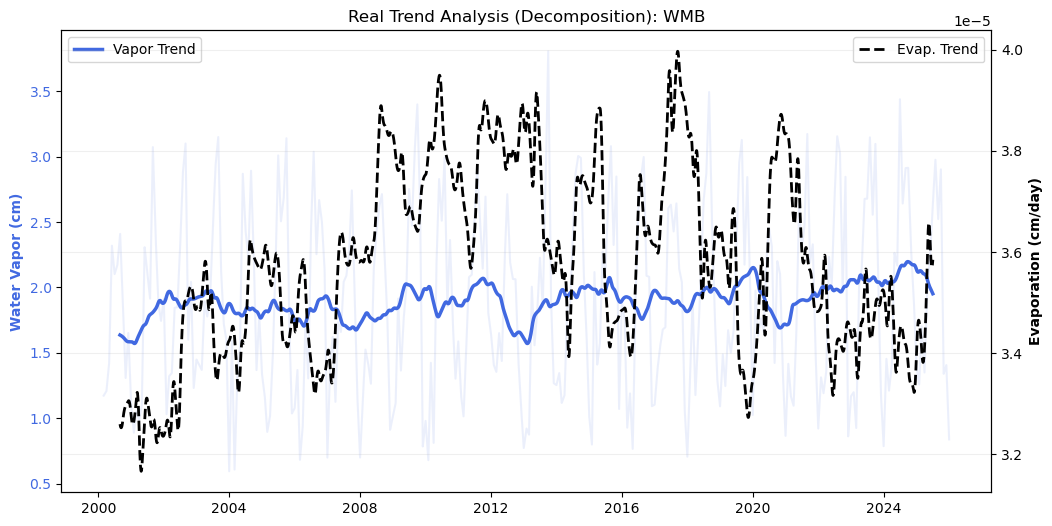

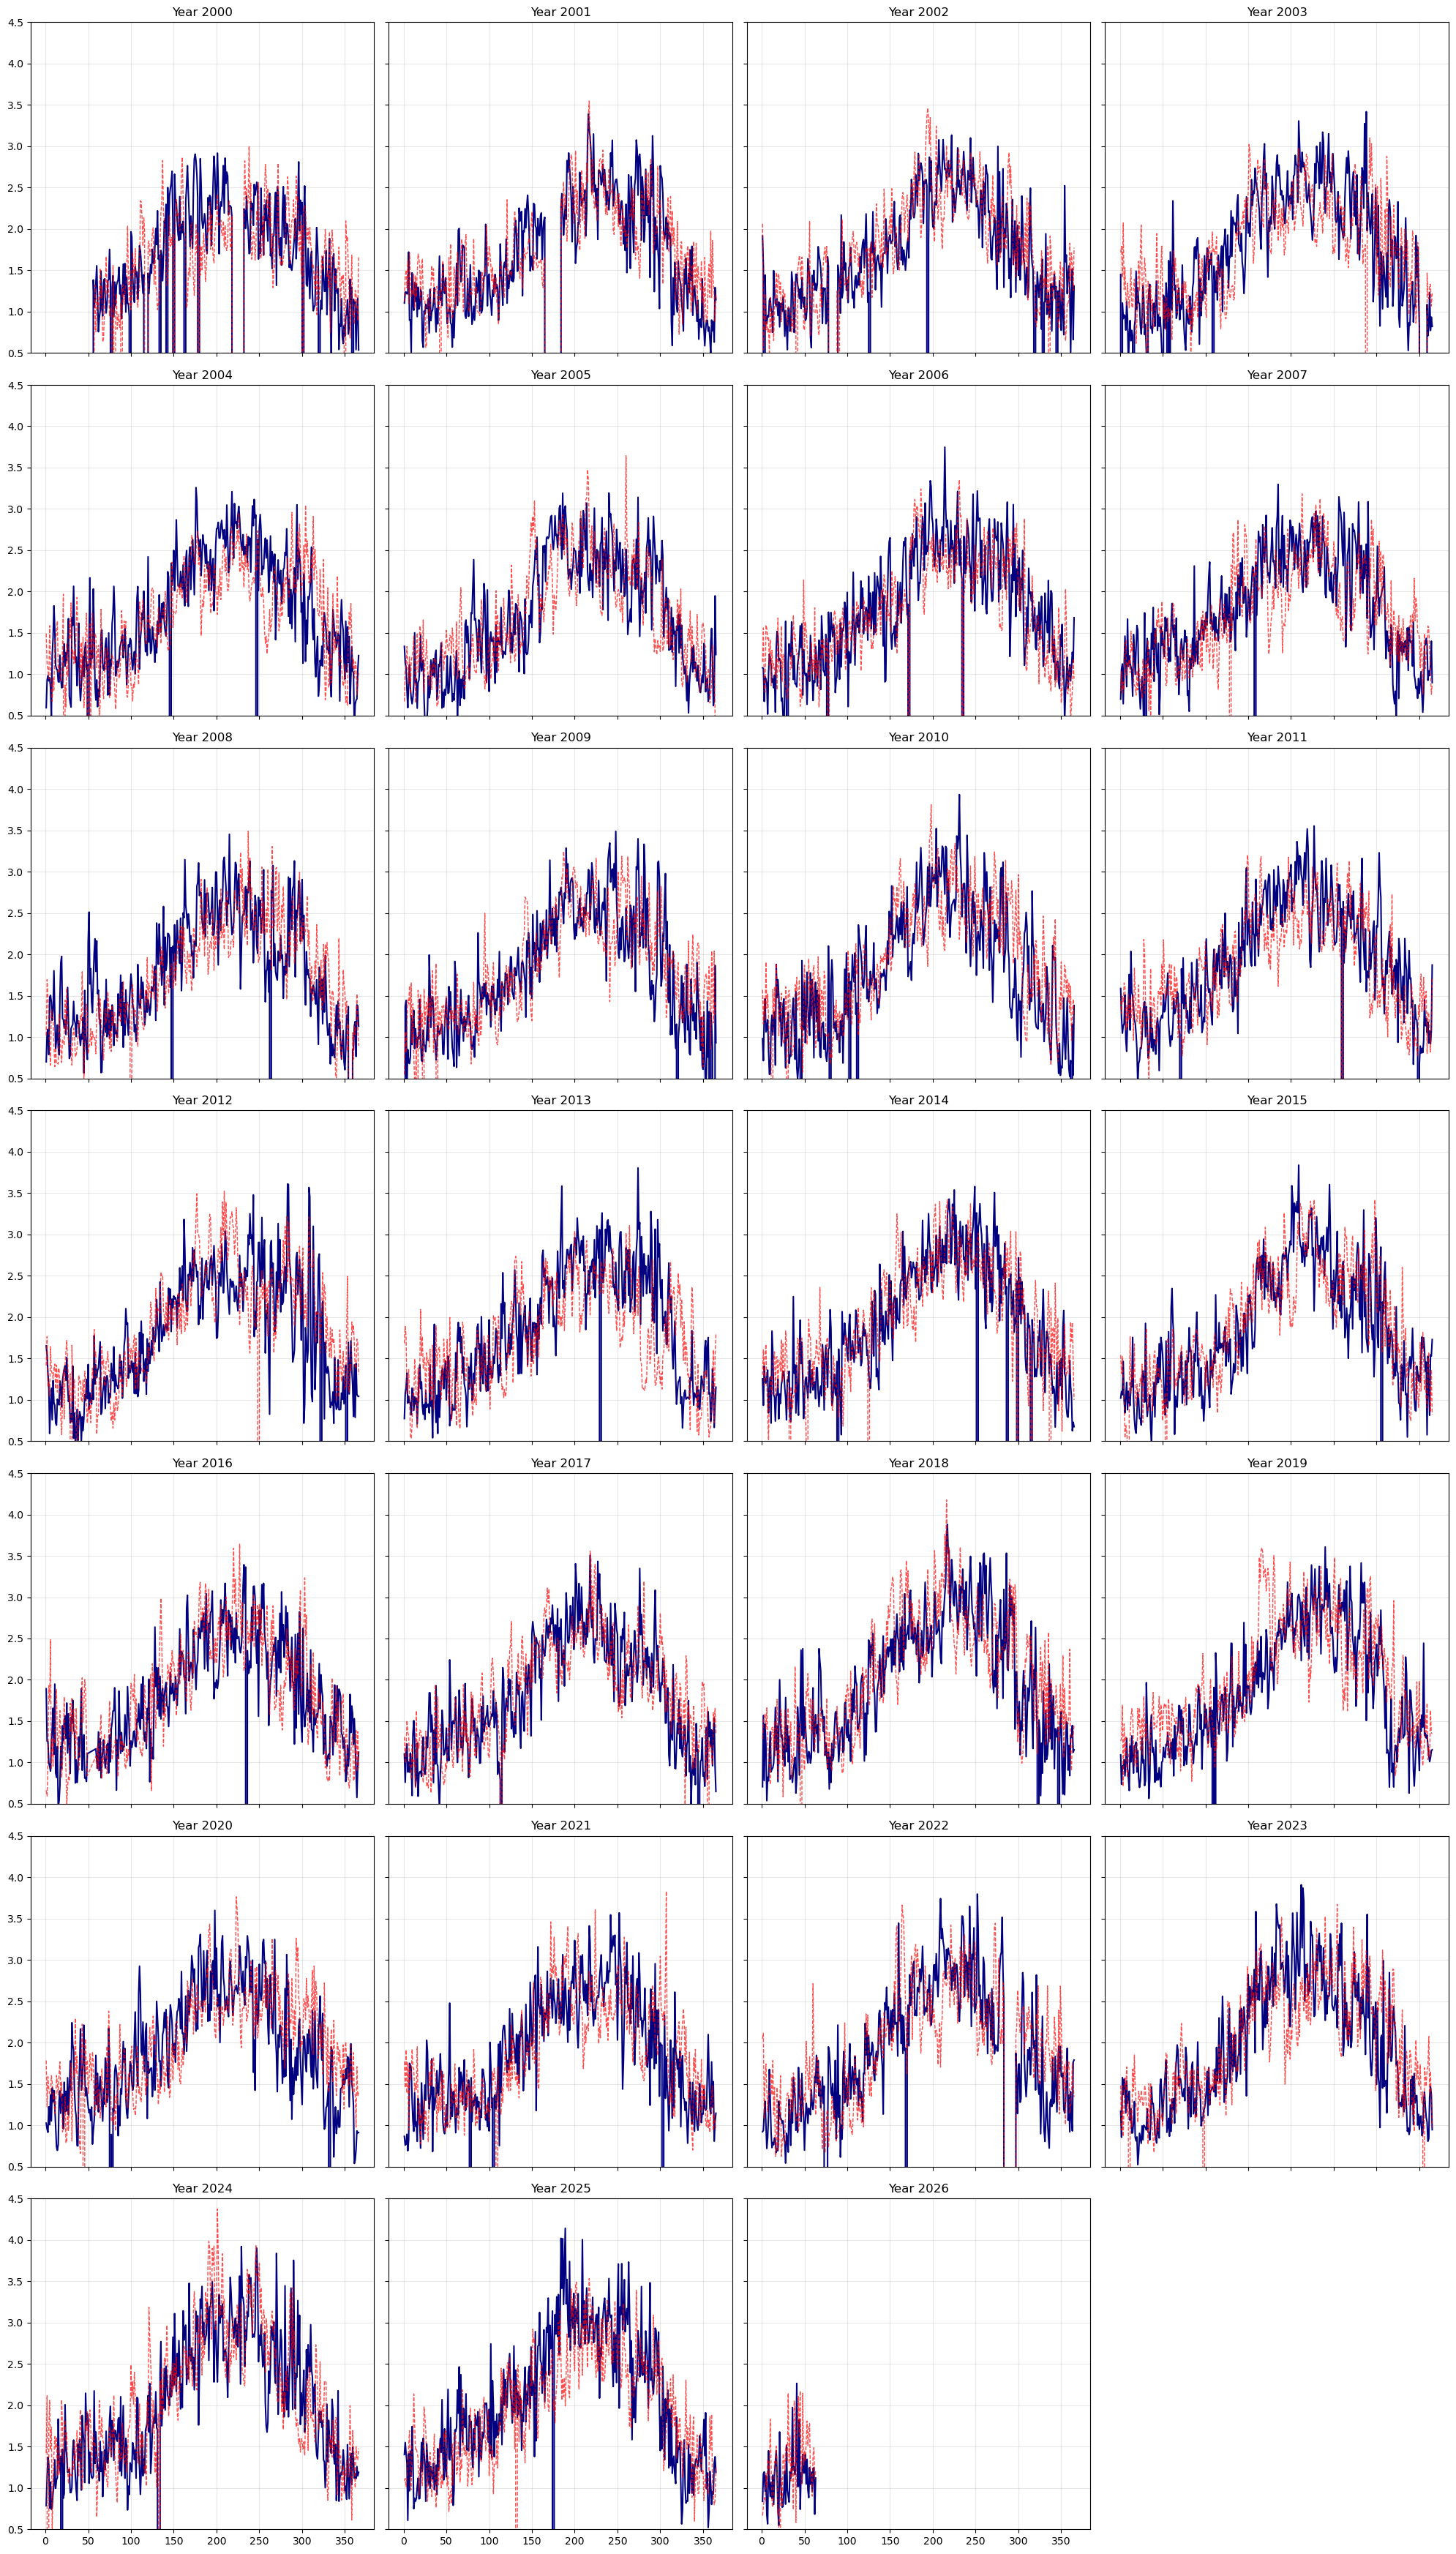

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math
from scipy.stats import pearsonr, linregress
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Path Configuration
base_path = os.path.join(os.path.expanduser("~"), "Desktop", "COSES UNI", "TFG", "DATOS")

# 2. Real Trend Analysis (Trend)
def analyze_unified_trend_7_3(df_vap, df_evap, site_name, color_main):
    # Synchronization and continuous series preparation for trend extraction
    df = pd.merge(df_vap[['date', 'value']], df_evap[['date', 'value']], on='date', suffixes=('_vap', '_evap'))
    df = df.sort_values('date').set_index('date')
    
    # Daily resampling to ensure a continuous series for seasonal_decompose
    df_resampled = df.resample('D').mean().interpolate(method='linear')
    
    # Seasonal Decomposition to extract the real TREND (annual period)
    res_vap = seasonal_decompose(df_resampled['value_vap'], model='additive', period=365)
    res_evap = seasonal_decompose(df_resampled['value_evap'], model='additive', period=365)
    
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # TPW Axis (Vapor - Atmospheric Stock)
    ax1.plot(df_resampled.index, df_resampled['value_vap'], color=color_main, alpha=0.1)
    ax1.plot(res_vap.trend.index, res_vap.trend, color=color_main, linewidth=2.5, label='Vapor Trend')
    ax1.set_ylabel('Water Vapor (cm)', color=color_main, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_main)

    # Secondary Axis (Evaporation - Moisture Source)
    ax2 = ax1.twinx()
    ax2.plot(res_evap.trend.index, res_evap.trend, color='black', linewidth=2, linestyle='--', label='Evap. Trend')
    ax2.set_ylabel('Evaporation (cm/day)', color='black', fontweight='bold')
    
    plt.title(f"Real Trend Analysis (Decomposition): {site_name}")
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.show()

# 3. Annual Evolution (Grid 2000-2026)
# This function generates a grid of annual cycles to observe interannual variability
def plot_robust_annual_evolution(wmb_file, emb_file):
    df_w = pd.read_csv(os.path.join(base_path, wmb_file), skiprows=8, sep=None, engine='python')
    df_e = pd.read_csv(os.path.join(base_path, emb_file), skiprows=8, sep=None, engine='python')

    # Cleaning whitespace and standardizing column names
    df_w.columns = df_w.columns.str.strip()
    df_e.columns = df_e.columns.str.strip()
    
    col_f, col_v = df_w.columns[0], df_w.columns[1]
    
    # Data Preparation and cleaning of sensor errors
    for df in [df_w, df_e]:
        df[col_f] = pd.to_datetime(df[col_f])
        df[col_v] = pd.to_numeric(df[col_v], errors='coerce')
        df.dropna(subset=[col_v], inplace=True)
        df['Year'] = df[col_f].dt.year
        df['DayOfYear'] = df[col_f].dt.dayofyear

    # Identifying unique years for the grid layout
    years = sorted(df_w['Year'].unique())
    cols = 4
    rows = math.ceil(len(years) / cols)

    # Creating the 'small multiples' grid figure
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, year in enumerate(years):
        ax = axes[i]
        # Filtering data by specific year
        data_w = df_w[df_w['Year'] == year]
        data_e = df_e[df_e['Year'] == year]
        
        # Plotting WMB (Navy) and EMB (Red) daily cycles
        ax.plot(data_w['DayOfYear'], data_w[col_v], color='navy', linewidth=1.5, label='WMB' if i==0 else "")
        ax.plot(data_e['DayOfYear'], data_e[col_v], color='red', linewidth=1, linestyle='--', alpha=0.7, label='EMB' if i==0 else "")
        ax.set_title(f"Year {year}")
        ax.set_ylim(0.5, 4.5) # Consistent scale for cross-year comparison
        ax.grid(True, alpha=0.3)

    # Remove extra/unused subplots in the matrix
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
analyze_unified_trend_7_3(df_wmb_vap, df_wmb_evap, "WMB", "royalblue")
plot_robust_annual_evolution("WMBwatervapor.csv", "EMBwatervapor.csv")

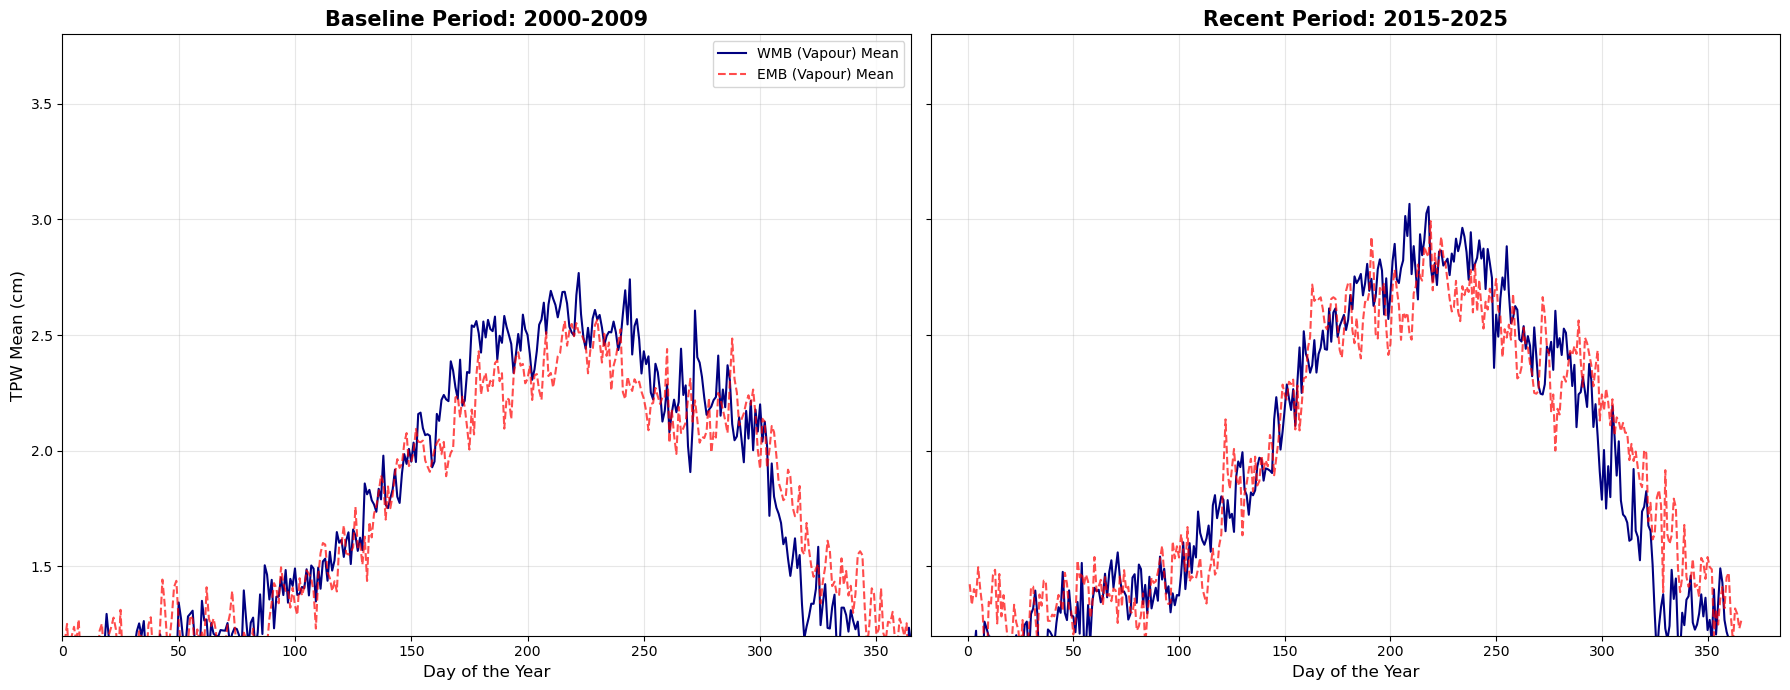

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definition of optimized sub-periods based on breakpoint analysis
# Period 1: Historical baseline before the detected shift (2000-2009)
# Period 2: Recent intensified regime (2015-2025)
# Note: 2010-2014 is excluded to isolate the transition phase
sub_p1 = (2000, 2009)
sub_p2 = (2015, 2025)

col_date = 'date'
col_value = 'value'

# 2. Daily climatological mean processing
def get_climatological_mean(df, years):
    # Filter data by the specified year range
    mask = (df[col_date].dt.year >= years[0]) & (df[col_date].dt.year <= years[1])
    # Group by day of the year (1-366) to obtain the mean seasonal cycle for the period
    return df[mask].groupby(df[col_date].dt.dayofyear)[col_value].mean()

# Calculate means for each basin and period
wmb_mean_p1 = get_climatological_mean(df_wmb_vap, sub_p1)
emb_mean_p1 = get_climatological_mean(df_emb_vap, sub_p1)

wmb_mean_p2 = get_climatological_mean(df_wmb_vap, sub_p2)
emb_mean_p2 = get_climatological_mean(df_emb_vap, sub_p2)

# 3. Figure initialization (Two-panel structure)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# --- LEFT PANEL: BASELINE (2000-2009 Means) ---
ax1.plot(wmb_mean_p1.index, wmb_mean_p1.values, color='navy', label='WMB (Vapour) Mean')
ax1.plot(emb_mean_p1.index, emb_mean_p1.values, color='red', linestyle='--', alpha=0.7, label='EMB (Vapour) Mean')

ax1.set_title(f"Baseline Period: {sub_p1[0]}-{sub_p1[1]}", fontsize=15, fontweight='bold')
ax1.set_ylabel("TPW Mean (cm)", fontsize=12)
ax1.set_xlabel("Day of the Year", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- RIGHT PANEL: RECENT (2015-2025 Means) ---
ax2.plot(wmb_mean_p2.index, wmb_mean_p2.values, color='navy')
ax2.plot(emb_mean_p2.index, emb_mean_p2.values, color='red', linestyle='--', alpha=0.7)

ax2.set_title(f"Recent Period: {sub_p2[0]}-{sub_p2[1]}", fontsize=15, fontweight='bold')
ax2.set_xlabel("Day of the Year", fontsize=12)
ax2.grid(True, alpha=0.3)

# Set physical limits for comparison (range based on Palau et al., 2017)
plt.ylim(1.2, 3.8) 
plt.tight_layout()
ax1.set_xlim(0, 365)
plt.show()

In [65]:
from scipy.stats import kurtosis, skew
import pandas as pd

def annual_statistical_evolution_table(df, site_name):
    stats_years = []
    
    df_filtered = df[df['date'].dt.year <= 2025].copy()
    
    # Grouping by year from the date column
    for year, group in df_filtered.groupby(df_filtered['date'].dt.year):
        stats_years.append({
            'Year': year,
            'Mean (cm)': group['value'].mean(),
            'Sigma (Std)': group['value'].std(),
            'Kurtosis': kurtosis(group['value']),
            'Skewness': skew(group['value'])
        })
    
    df_res = pd.DataFrame(stats_years)
    print(f"\n--- ANNUAL STATISTICS: {site_name} (2000-2025) ---")
    print(df_res.to_string(index=False))
    return df_res

# Execute to detect intensity changes
stats_wmb = annual_statistical_evolution_table(df_wmb_vap, "WMB")
stats_emb = annual_statistical_evolution_table(df_emb_vap, "EMB")


--- ANNUAL STATISTICS: WMB (2000-2025) ---
 Year  Mean (cm)  Sigma (Std)  Kurtosis  Skewness
 2000   1.759804     0.560348 -0.825935 -0.018716
 2001   1.690413     0.655011 -0.923762  0.314534
 2002   1.738355     0.613800 -0.882191  0.296407
 2003   1.790560     0.689247 -1.064025  0.040294
 2004   1.779205     0.662690 -1.060201  0.137099
 2005   1.701945     0.695092 -1.087355  0.172310
 2006   1.807147     0.675438 -0.833298  0.168905
 2007   1.791387     0.636740 -0.869924  0.085921
 2008   1.798859     0.663676 -0.969743  0.235426
 2009   1.794998     0.700388 -0.891154  0.256960
 2010   1.821418     0.736147 -0.752031  0.271373
 2011   1.924939     0.687536 -0.956588  0.133852
 2012   1.800448     0.700142 -0.878409  0.204048
 2013   1.853566     0.721997 -1.084286  0.210880
 2014   1.926885     0.719850 -0.998783  0.222689
 2015   1.858382     0.722168 -0.808378  0.339358
 2016   1.811415     0.638605 -0.816012  0.264483
 2017   1.814107     0.675340 -0.938012  0.190028
 2018 

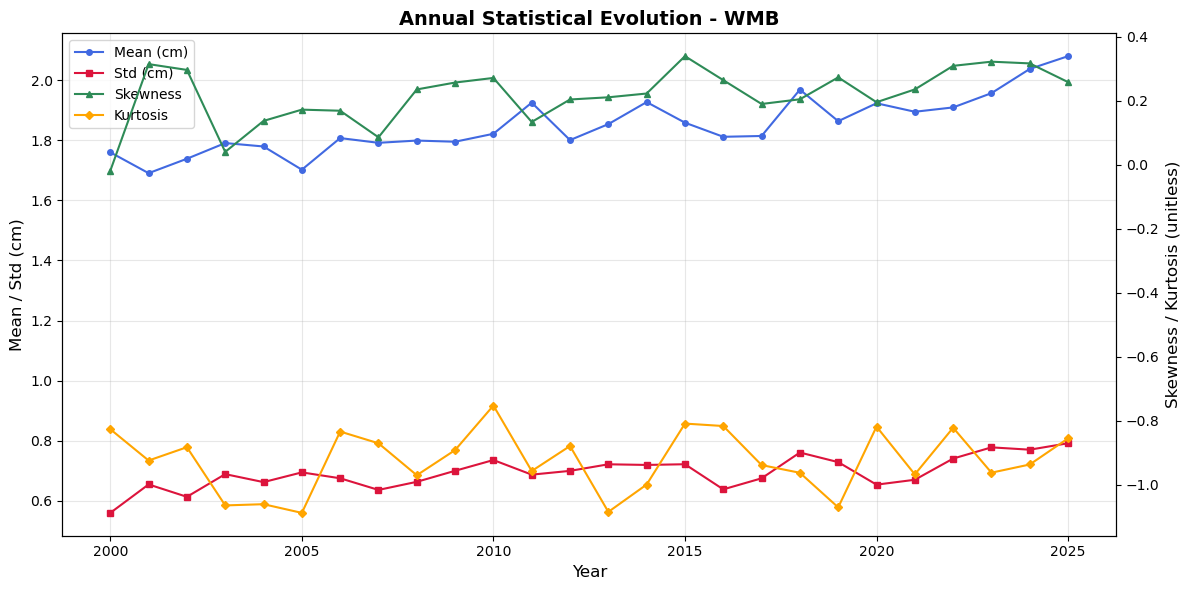

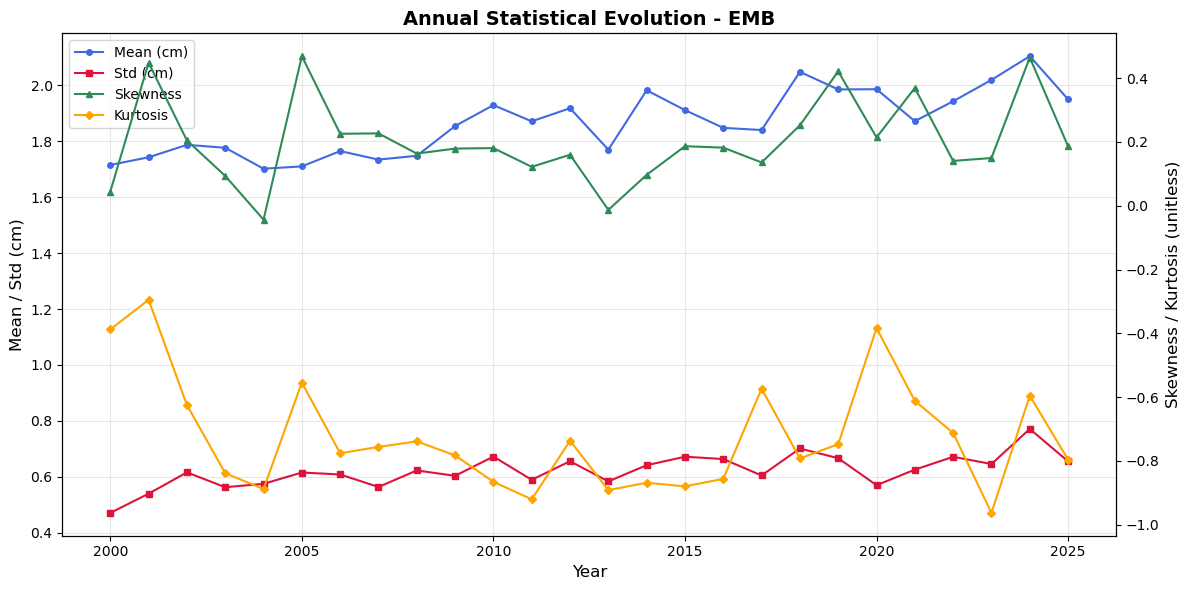

In [81]:
plot_combined_stats(stats_wmb, "WMB")
plot_combined_stats(stats_emb, "EMB")

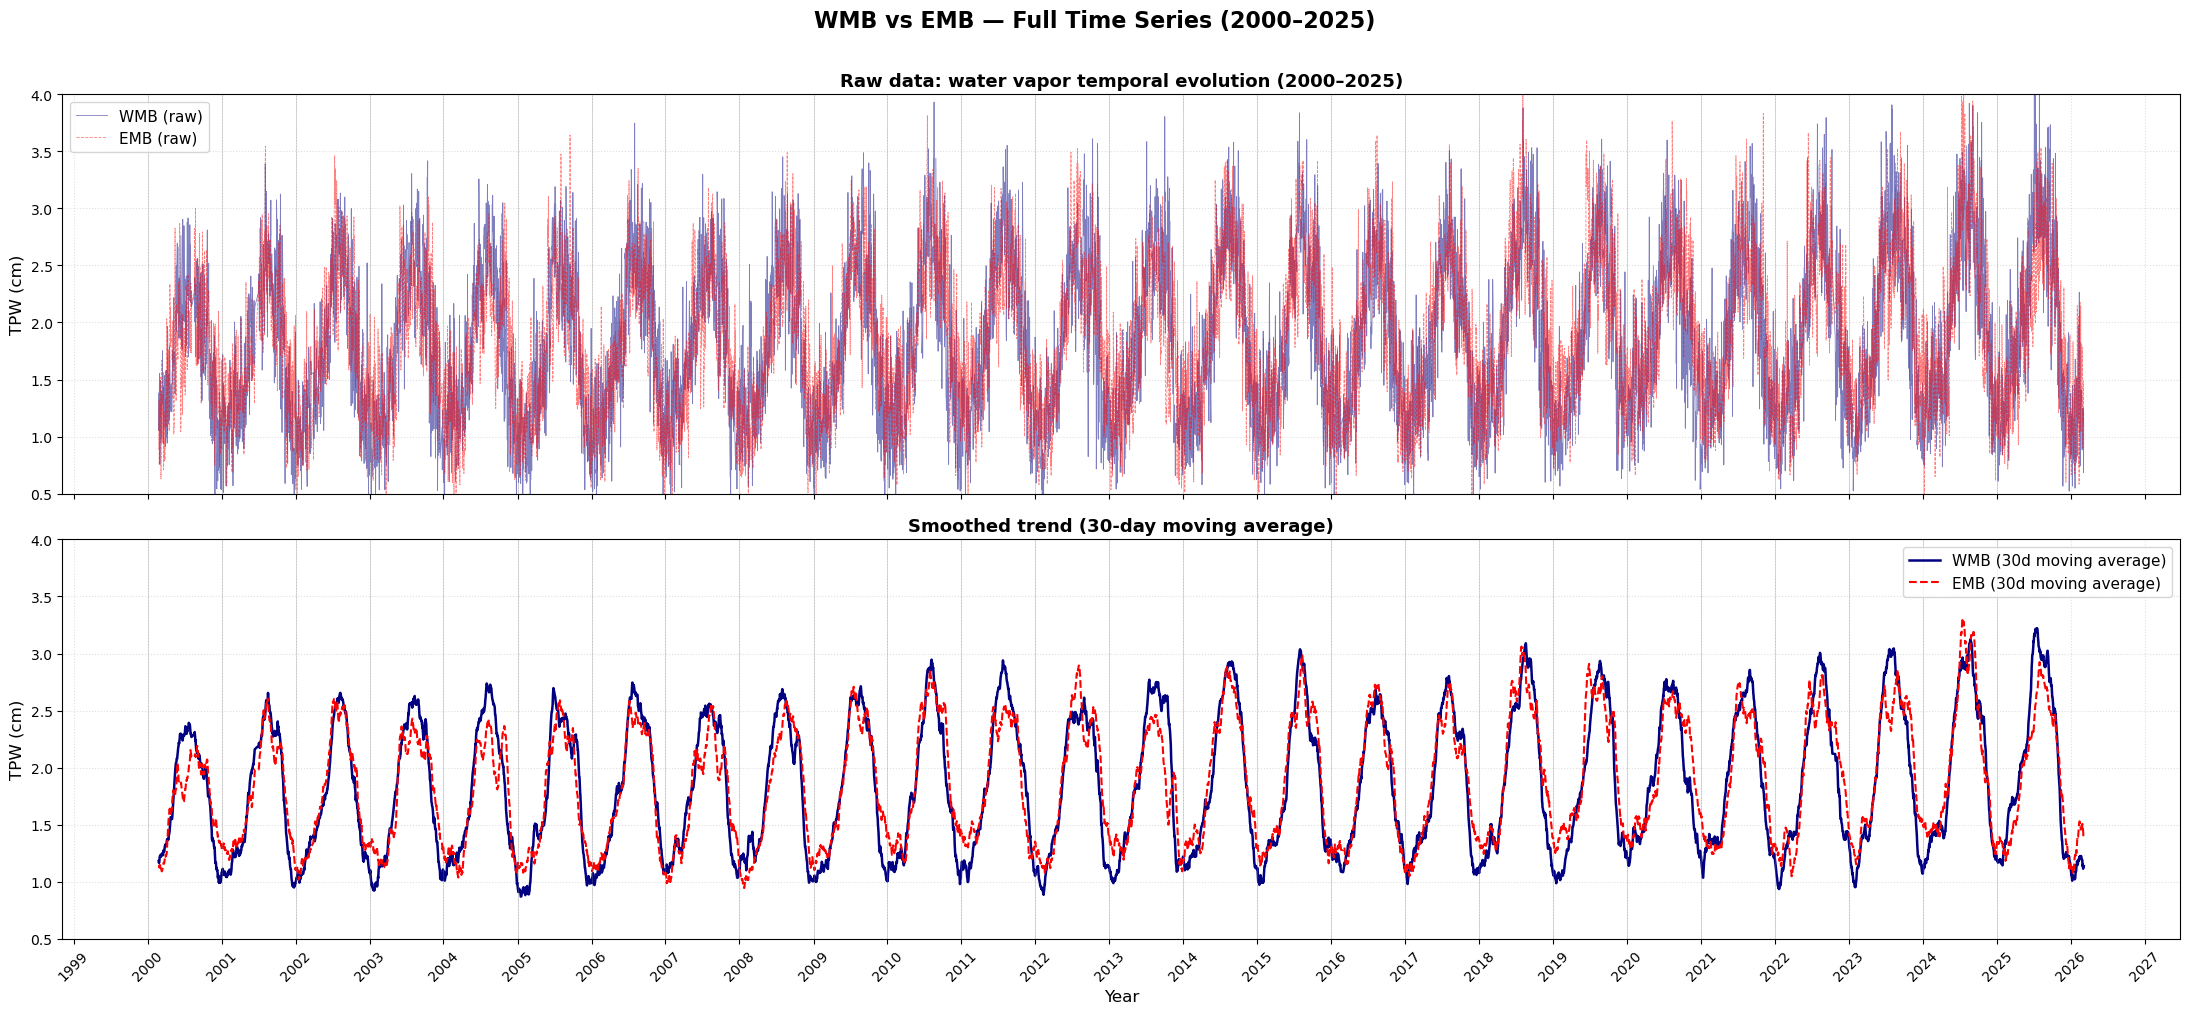

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Configuration of the data path
base_path = os.path.join(os.path.expanduser("~"), "Desktop", "COSES UNI", "TFG", "DATOS")

def plot_full_timeseries(wmb_file, emb_file):
    # Read files
    df_w = pd.read_csv(os.path.join(base_path, wmb_file), skiprows=8, sep=None, engine='python')
    df_e = pd.read_csv(os.path.join(base_path, emb_file), skiprows=8, sep=None, engine='python')

    for df in [df_w, df_e]:
        df.columns = df.columns.str.strip()

    date_col = df_w.columns[0]
    value_col = df_w.columns[1]

    # Process and clean 
    for df in [df_w, df_e]:
        df[date_col] = pd.to_datetime(df[date_col])
        df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
        df.dropna(subset=[value_col], inplace=True)
        df.drop(df[df[value_col] < 0].index, inplace=True)

    df_w = df_w.sort_values(date_col)
    df_e = df_e.sort_values(date_col)

    # Smoothing with moving average (30 days) to see trends
    window = 30 
    df_w['smooth'] = df_w[value_col].rolling(window=window, center=True, min_periods=1).mean()
    df_e['smooth'] = df_e[value_col].rolling(window=window, center=True, min_periods=1).mean()

    # Figure with two panels: raw data + smoothing
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 10), sharex=True)

    # Top panel
    ax1.plot(df_w[date_col], df_w[value_col],
             color='navy', linewidth=0.6, alpha=0.5, label='WMB (raw)')
    ax1.plot(df_e[date_col], df_e[value_col],
             color='red',  linewidth=0.6, alpha=0.5, linestyle='--', label='EMB (raw)')
    ax1.set_ylabel("TPW (cm)", fontsize=12)
    ax1.set_title("Raw data: water vapor temporal evolution (2000–2025)",
                  fontsize=13, fontweight='bold')
    ax1.set_ylim(0.5, 4.0)
    ax1.grid(True, linestyle=':', alpha=0.4)
    ax1.legend(fontsize=11)

    # Bottom panel
    ax2.plot(df_w[date_col], df_w['smooth'],
             color='navy', linewidth=1.8, label=f'WMB ({window}d moving average)')
    ax2.plot(df_e[date_col], df_e['smooth'],
             color='red',  linewidth=1.5, linestyle='--', label=f'EMB ({window}d moving average)')
    ax2.set_ylabel("TPW (cm)", fontsize=12)
    ax2.set_xlabel("Year", fontsize=12)
    ax2.set_title(f"Smoothed trend ({window}-day moving average)",
                  fontsize=13, fontweight='bold')
    ax2.set_ylim(0.5, 4.0)
    ax2.grid(True, linestyle=':', alpha=0.4)
    ax2.legend(fontsize=11)

    # X axis: one tick per year
    for ax in [ax1, ax2]:
        ax.xaxis.set_major_locator(mdates.YearLocator(1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.xticks(rotation=45)

    # Vertical year lines for orientation 
    years = pd.date_range(start='2000-01-01', end='2025-12-31', freq='YS')
    for ax in [ax1, ax2]:
        for y in years:
            ax.axvline(y, color='gray', linewidth=0.4, alpha=0.5)

    plt.suptitle("WMB vs EMB — Full Time Series (2000–2025)",
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()

    # Show plot
    plt.show()

plot_full_timeseries("WMBwatervapor.csv", "EMBwatervapor.csv")